In [1]:
import pickle as pkl
import numpy as np 
import hist
from collections import defaultdict
import mplhep as hep

In [4]:
prepend = "../inputs/rho/"
filenames = [
    prepend + "jms_pythia_2016_syst.pkl",
    prepend + "jms_pythia_2016APV_syst.pkl",
    prepend + "jms_pythia_2017_syst.pkl",
    prepend + "jms_pythia_2018_syst.pkl",
]
filename_herwig = prepend + "herwig_all.pkl"

filename_jk_data = [
    #prepend + "data_2016_jk.pkl",
    #prepend + "data_2016APV_jk.pkl",
    prepend + "data_2017_jk.pkl",
    prepend + "data_2018_jk.pkl",
]

In [5]:
def group(h: hist.Hist, oldname: str, newname: str, grouping: dict[str, list[str]]):
    hnew = hist.Hist(
        hist.axis.StrCategory(grouping, name=newname),
        *(ax for ax in h.axes if ax.name != oldname),
        storage=h.storage_type,
    )
    for i, indices in enumerate(grouping.values()):
        hnew.view(flow=True)[i] = h[{oldname: indices}][{oldname: sum}].view(flow=True)

    return hnew

ratio_data_mc = [0.76056319, 0.97830354, 1.24357577, 1.20827736]

In [6]:
keymap = {
    "2016": "pythia_UL16NanoAODv9",
    "2016APV": "pythia_UL16NanoAODAPVv9",
    "2017": "pythia_UL17NanoAODv9",
    "2018": "pythia_UL18NanoAODv9",
}
htbin_list = ['pythia_HT-100to200', 'pythia_HT-200to400', 'pythia_HT-400to600', 'pythia_HT-1200to2500', 'pythia_HT-2500toInf', 'pythia_HT-800to1200', 'pythia_HT-600to800']

In [7]:
response_dict = {}
for filename in filenames:
    era = filename.split('_')[2]
    print(f"Processing era: {era}")
    key = keymap[era]
    response_dict.setdefault('u', {})
    response_dict.setdefault('g', {})

    
    grouping = defaultdict(list)
    grouping[key] = htbin_list
    with open(filename, "rb") as f:
        data = pkl.load(f)
        # ensure top-level 'u' and 'g' keys exist
        
        if era == "2016APV" or era == "2016":
            response_dict['u'][key] = data['response_matrix_rho_u'].project('ptreco','dataset', 'ptgen', 'mpt_gen',  'mpt_reco', 'systematic')
            response_dict['g'][key] = data['response_matrix_rho_g'].project('ptreco','dataset', 'ptgen', 'mpt_gen',  'mpt_reco', 'systematic')
            continue
        h_old = data['response_matrix_rho_u'].project('ptreco','dataset', 'ptgen', 'mpt_gen',  'mpt_reco', 'systematic')
        #h_new = group(h_old, oldname="dataset", newname="dataset", grouping=dict(grouping))
        response_dict['u'][key] = h_old

        h_old = data['response_matrix_rho_g'].project('ptreco','dataset', 'ptgen', 'mpt_gen',  'mpt_reco', 'systematic')
        #h_new = group(h_old, oldname="dataset", newname="dataset", grouping=dict(grouping))
        response_dict['g'][key] = h_old

        for i in range(4):
            response_dict['u'][key].view()[i] *= ratio_data_mc[i]
            response_dict['g'][key].view()[i] *= ratio_data_mc[i]
 

Processing era: 2016
Processing era: 2016APV
Processing era: 2017
Processing era: 2018


In [9]:
response_dict['u']['pythia_UL16NanoAODv9']

Hist(
  Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
  StrCategory(['pythia_UL16NanoAODAPVv9'], name='dataset'),
  Variable([0, 200, 290, 400, 13000], name='ptgen', label='$p_{T,GEN}$ (GeV)'),
  Variable([-10, -6, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0], name='mpt_gen', label='$\\log_{10}(\\rho^2)$'),
  Variable(array([-10.  ,  -8.  ,  -6.  ,  -5.5 ,  -5.  ,  -4.75,  -4.5 ,  -4.25,
        -4.  ,  -3.75,  -3.5 ,  -3.25,  -3.  ,  -2.75,  -2.5 ,  -2.25,
        -2.  ,  -1.75,  -1.5 ,  -1.25,  -1.  ,  -0.75,  -0.5 ,  -0.25,
         0.  ]), name='mpt_reco', label='$\\log_{10}(\\rho^2)$ (Detector)'),
  StrCategory(['nominal', 'puUp', 'puDown', 'elerecoUp', 'elerecoDown', 'eleidUp', 'eleidDown', 'eletrigUp', 'eletrigDown', 'murecoUp', 'murecoDown', 'muidUp', 'muidDown', 'mutrigUp', 'mutrigDown', 'muisoUp', 'muisoDown', 'pdfUp', 'pdfDown', 'q2Up', 'q2Down', 'l1prefiringUp', 'l1prefiringDown', 'JERUp', 'JERDown', 'JMSUp', 'JMSDown', 'JMRUp', 'JM

(Experiment Label: Text(0.04967741935483871, 0.95, 'CMS'),
 Experiment Text: Text(0.19553763440860214, 0.9045454545454545, 'Simulation Internal'),
 Luminosity Text: Text(1.0, 1.0, '138 $\\mathrm{fb^{-1}}$ (13 TeV)'),
 None)

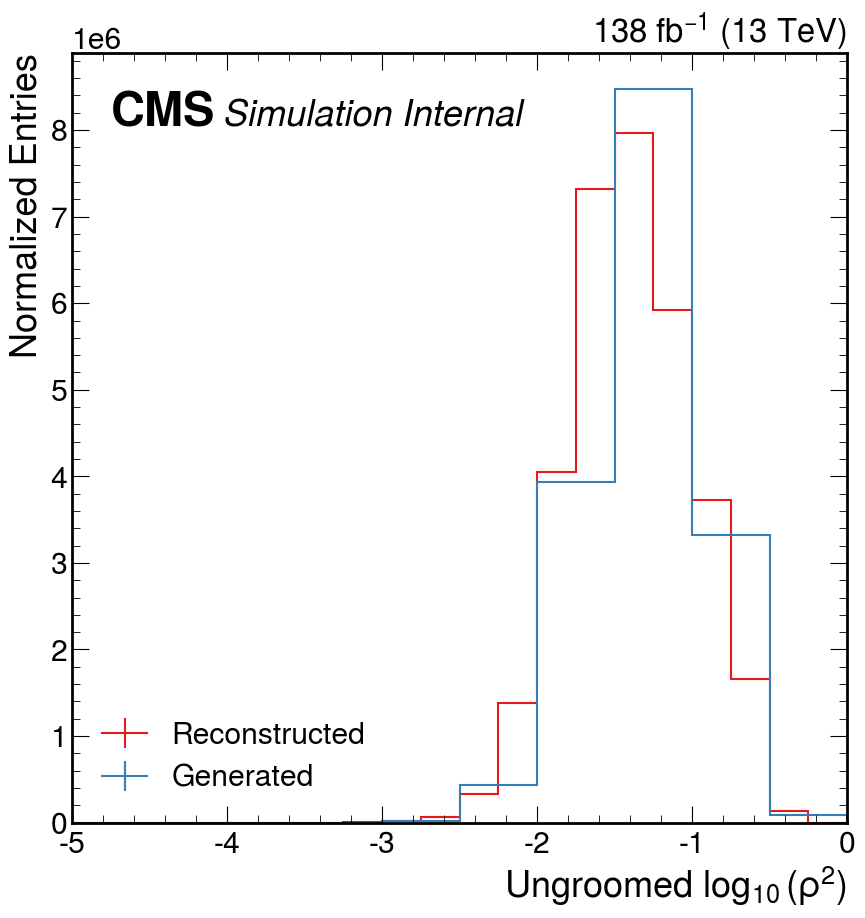

In [6]:
from cycler import cycler
import matplotlib.pyplot as plt
hep.style.use("CMS")  # Use the CMS style for plots
new_colors = plt.get_cmap('Set1').colors
plt.rcParams['axes.prop_cycle'] = cycler(color=new_colors)
response_dict['u']['pythia_UL18NanoAODv9'].project('mpt_reco').plot(label = "Reconstructed", binwnorm = 1)
response_dict['u']['pythia_UL18NanoAODv9'].project('mpt_gen').plot(label = "Generated", binwnorm = 1)
plt.xlim(-5, 0)
plt.xlabel(r"Ungroomed $\log_{10}(\rho^2)$")
plt.ylabel("Normalized Entries")
plt.legend(loc = "lower left")
hep.cms.label("Internal", data = False, lumi=138, loc = 1)


In [7]:
print(response_dict['g']['pythia_UL16NanoAODv9'].sum())
print(response_dict['g']['pythia_UL16NanoAODAPVv9'].sum())
print(response_dict['g']['pythia_UL17NanoAODv9'].sum())
print(response_dict['g']['pythia_UL18NanoAODv9'].sum())

WeightedSum(value=2.05786e+06, variance=258132)
WeightedSum(value=2.60589e+06, variance=405400)
WeightedSum(value=5.50437e+06, variance=682845)
WeightedSum(value=8.09325e+06, variance=982207)


In [8]:
print(response_dict['u']['pythia_UL16NanoAODv9'].sum())
print(response_dict['u']['pythia_UL16NanoAODAPVv9'].sum())
print(response_dict['u']['pythia_UL17NanoAODv9'].sum())
print(response_dict['u']['pythia_UL18NanoAODv9'].sum())

WeightedSum(value=2.06918e+06, variance=259527)
WeightedSum(value=2.61957e+06, variance=407553)
WeightedSum(value=5.53411e+06, variance=686624)
WeightedSum(value=8.13747e+06, variance=987790)


In [9]:
# grouping = defaultdict(list)
# grouping[new_key].append(ds)
# h = group(h, oldname="dataset", newname="dataset", grouping=dict(grouping))

In [10]:
correlation_dic = {
    'JES_AbsoluteMPFBias': 1,
    'JES_AbsoluteScale': 1,
    'JES_AbsoluteStat': 0,
    'JES_FlavorQCD': 1,
    'JES_Fragmentation': 1,
    'JES_PileUpDataMC': 0.5,
    'JES_PileUpPtBB': 0.5,
    'JES_PileUpPtEC1': 0.5,
    'JES_PileUpPtEC2': 0.5,
    'JES_PileUpPtHF': 0.5,
    'JES_PileUpPtRef': 0.5,
    'JES_RelativeFSR': 0.5,
    'JES_RelativeJEREC1': 0,
    'JES_RelativeJEREC2': 0,
    'JES_RelativeJERHF': 0.5,
    'JES_RelativePtBB': 0.5,
    'JES_RelativePtEC1': 0,
    'JES_RelativePtEC2': 0,
    'JES_RelativePtHF': 0.5,
    'JES_RelativeBal': 0.5,
    'JES_RelativeSample': 0,
    'JES_RelativeStatEC': 0,
    'JES_RelativeStatFSR': 0,
    'JES_RelativeStatHF': 0,
    'JES_SinglePionECAL': 1,
    'JES_SinglePionHCAL': 1,
    'JES_TimePtEta': 0,
    'JER': 0,
}

jes_sys_list = ['JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown',
                'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp',
                'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown',
                'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 
                'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up',
                'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown',
                'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_RelativePtEC2Up', 'JES_RelativePtEC2Down',
                'JES_RelativePtHFUp', 'JES_RelativePtHFDown', 'JES_RelativeBalUp', 'JES_RelativeBalDown', 'JES_RelativeSampleUp', 'JES_RelativeSampleDown', 
                'JES_RelativeStatECUp', 'JES_RelativeStatECDown', 'JES_RelativeStatFSRUp', 'JES_RelativeStatFSRDown', 'JES_RelativeStatHFUp', 'JES_RelativeStatHFDown',
                'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_TimePtEtaUp', 'JES_TimePtEtaDown', 'JERUp', 'JERDown']


non_jes_sys_list = ['nominal', 'puUp', 'puDown', 'elerecoUp', 'elerecoDown',
                    'eleidUp', 'eleidDown', 'eletrigUp', 'eletrigDown', 'murecoUp',
                    'murecoDown', 'muidUp', 'muidDown', 'mutrigUp', 'muisoUp', 'muisoDown','mutrigDown', 'pdfUp',
                    'pdfDown', 'q2Up', 'q2Down', 'l1prefiringUp', 'l1prefiringDown', 
                     'JMRUp', 'JMRDown', 'JMSUp', 'JMSDown']


non_jes_sys_list_up = [sys for sys in non_jes_sys_list if sys[-2:] == 'Up' ]
non_jes_sys_list_down = [sys for sys in non_jes_sys_list if sys[-4:] == 'Down' ]

jes_sys_list_up = [sys for sys in jes_sys_list if sys[-2:] == 'Up' ]
jes_sys_list_down = [sys for sys in jes_sys_list if sys[-4:] == 'Down' ]

In [11]:
# #test
# jes_sys_list_up = []
# jes_sys_list_down = ['nominal']

# # non_jes_sys_list_up = ['nominal']
# # non_jes_sys_list_down = ['nominal']

In [12]:
# sys_matrix_dic_up = {}
# sys_matrix_var_dic_up = {}
# sys_matrix_dic_down = {}
# sys_matrix_var_dic_down = {}
# non_jes_sys_matrix_dic_up = {}
# non_jes_sys_matrix_dic_down = {}
# groomed = True
# if not groomed:
#     response = response_dict['u']
# else:
#     response = response_dict['g']

# for sys in jes_sys_list_up:
#     # keep both values() and variances() — do not compute variances manually or apply correlations here
#     # nominal: values + variances per year
#     m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2016_var = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2017_var = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2018_var = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()

#     # systematic: values + variances per year
#     m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2016_var = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2017_var = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2018_var = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()


    
#     # combine years by summing (keep values and variances separate)
#     m_nom_vals = m_nom_2016 + m_nom_2017 + m_nom_2018
#     m_nom_vars = m_nom_2016_var + m_nom_2017_var + m_nom_2018_var

#     m_sys_vals = m_sys_2016 + m_sys_2017 + m_sys_2018
#     m_sys_vars = m_sys_2016_var + m_sys_2017_var + m_sys_2018_var

#     # store both representations; keep original-named m_nom_2016/2017/2018 (values) so later code that sums them continues to work
#     sys_matrix_dic_up[sys] = m_sys_vals
#     sys_matrix_var_dic_up[sys] = m_sys_vars
#     sys_matrix_dic_up[sys + '_nom_vals'] = m_nom_vals
#     sys_matrix_var_dic_up[sys + '_nom_vars'] = m_nom_vars

#     non_jes_sys_matrix_dic_up[sys + '_vals'] = m_sys_vals
    
#     sys_matrix_dic_down[sys] = 
#     #non_jes_sys_matrix_dic_down[sys] = variation
# m_nom = m_nom_2016 + m_nom_2017 + m_nom_2018

# # sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
# # sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [20]:
sys_matrix_dic_up = {}

groomed = True
if not groomed:
    response = response_dict['u']
else:
    response = response_dict['g']





for sys in jes_sys_list_up:
    m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response['pythia_UL16NanoAODAPVv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()

    variance = np.array([response[era][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').variances() for era in ['pythia_UL16NanoAODv9', 'pythia_UL16NanoAODAPVv9', 'pythia_UL17NanoAODv9', 'pythia_UL18NanoAODv9']]).sum(axis = 0)
    
    m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
        response['pythia_UL16NanoAODAPVv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-2]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_up[sys+'_corr'] = m_corr
    sys_matrix_dic_up[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_up[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_up[sys+'_uncorr_2018'] = m_uncorr_2018
    
non_jes_sys_matrix_dic_up = {}
for sys in non_jes_sys_list_up:
    sys_matrix_dic_up[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL16NanoAODAPVv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()

    non_jes_sys_matrix_dic_up[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL16NanoAODAPVv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()



sys_matrix_dic_down = {}
non_jes_sys_matrix_dic_down = {}
for sys in jes_sys_list_down:
    m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
                 response['pythia_UL16NanoAODAPVv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
                 response['pythia_UL16NanoAODAPVv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-4]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_down[sys+'_corr'] = m_corr
    sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018
    

for sys in non_jes_sys_list_down:
    sys_matrix_dic_down[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL16NanoAODAPVv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
#                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values
    non_jes_sys_matrix_dic_down[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL16NanoAODAPVv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()


# sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
# sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [21]:
# groomed = False
if not groomed:
    response = response_dict['u']
else:
    response = response_dict['g']

sys_matrix_dic_up['nominal'] = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()  +\
            response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
                response['pythia_UL16NanoAODAPVv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
sys_matrix_dic_down['nominal'] = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()  +\
            response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
                response['pythia_UL16NanoAODAPVv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()

In [22]:
# with open(filename_herwig, "rb") as f:
#     data_herwig = pkl.load(f)
#     if not groomed:
#         sys_matrix_dic_up['herwig0Up'] = data_herwig['response_matrix_rho_u'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
#         sys_matrix_dic_down['herwig0Down'] = data_herwig['response_matrix_rho_u'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
#     else:
#         sys_matrix_dic_up['herwig0Up'] = data_herwig['response_matrix_rho_g'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
#         sys_matrix_dic_down['herwig0Down'] = data_herwig['response_matrix_rho_g'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()

In [23]:
filename_herwig_1 = prepend + "pythia_reweighted_all.pkl"
with open(filename_herwig_1, "rb") as f:
    data_herwig = pkl.load(f)
    if not groomed:
        sys_matrix_dic_up['herwigUp'] = data_herwig['response_matrix_rho_u'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
        sys_matrix_dic_down['herwigDown'] = data_herwig['response_matrix_rho_u'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
    else:
        sys_matrix_dic_up['herwigUp'] = data_herwig['response_matrix_rho_g'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
        sys_matrix_dic_down['herwigDown'] = data_herwig['response_matrix_rho_g'].project('ptgen','mpt_gen','ptreco','mpt_reco').values()

In [1]:
import os

out_dir = prepend  # uses the existing "./inputs/" variable
os.makedirs(out_dir, exist_ok=True)
if groomed:
    out_path = os.path.join(out_dir, "sys_matrix_dic_rho_groomed_v2.pkl")
else:
    out_path = os.path.join(out_dir, "sys_matrix_dic_rho_ungroomed_v2.pkl")

# merge up and down into a single dict, avoid double-counting 'nominal'
merged = dict(sys_matrix_dic_up)  # shallow copy of up
for k, v in sys_matrix_dic_down.items():
    if k == "nominal":
        continue  # skip duplicate nominal from the down dict
    if k in merged:
        # if a key collides, store the down version with a suffix
        merged_key = f"{k}_down"
        # ensure uniqueness
        i = 1
        unique_key = merged_key
        while unique_key in merged:
            unique_key = f"{merged_key}_{i}"
            i += 1
        merged[unique_key] = v
    else:
        merged[k] = v

with open(out_path, "wb") as f:
    pkl.dump(merged, f, protocol=4)

print(f"Saved {out_path} with {len(merged)} entries")

NameError: name 'prepend' is not defined

In [23]:
for k in sys_matrix_dic_up:
    if k.startswith("JER"):
        print(k)

JERUp_corr
JERUp_uncorr_2016
JERUp_uncorr_2017
JERUp_uncorr_2018


In [24]:
sys_matrix_dic_down['JMSDown'].sum(axis = (0,1,2)).sum()/sys_matrix_dic_down['herwigDown'].sum(axis = (0,1,2)).sum()


np.float64(1.0060686218508534)

In [88]:
response_dict['u']

{'pythia_UL16NanoAODv9': Hist(
   Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
   StrCategory(['pythia_UL16NanoAODAPVv9'], name='dataset'),
   Variable([0, 200, 290, 400, 13000], name='ptgen', label='$p_{T,GEN}$ (GeV)'),
   Variable([-10, -6, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0], name='mpt_gen', label='$\\log_{10}(\\rho^2)$'),
   Variable(array([-10.  ,  -8.  ,  -6.  ,  -5.5 ,  -5.  ,  -4.75,  -4.5 ,  -4.25,
         -4.  ,  -3.75,  -3.5 ,  -3.25,  -3.  ,  -2.75,  -2.5 ,  -2.25,
         -2.  ,  -1.75,  -1.5 ,  -1.25,  -1.  ,  -0.75,  -0.5 ,  -0.25,
          0.  ]), name='mpt_reco', label='$\\log_{10}(\\rho^2)$ (Detector)'),
   StrCategory(['nominal', 'puUp', 'puDown', 'elerecoUp', 'elerecoDown', 'eleidUp', 'eleidDown', 'eletrigUp', 'eletrigDown', 'murecoUp', 'murecoDown', 'muidUp', 'muidDown', 'mutrigUp', 'mutrigDown', 'muisoUp', 'muisoDown', 'pdfUp', 'pdfDown', 'q2Up', 'q2Down', 'l1prefiringUp', 'l1prefiringDown', 'JERUp', 'JERDown'

In [91]:
gen_edges = response_dict['u']['pythia_UL16NanoAODAPVv9'].axes['mpt_gen'].edges

In [18]:
import matplotlib.pyplot as plt
for i in range(1, 4):
    herwig_orig = sys_matrix_dic_up['herwig0Up'].sum(axis = (2,3))[i]
    herwig_rew = sys_matrix_dic_up['herwigUp'].sum(axis = (2,3))[i]
    herwig_orig = herwig_orig / herwig_orig.sum()
    herwig_rew = herwig_rew / herwig_rew.sum()
    plt.stairs(herwig_rew, gen_edges,label = "Reweighted Pythia")
    plt.stairs(herwig_orig, gen_edges,label = "Unweighted Herwig")
    plt.xlabel(rf" GEN $\log_{10}(\rho^2)$ ")
    plt.legend()
    plt.show()

KeyError: 'herwig0Up'

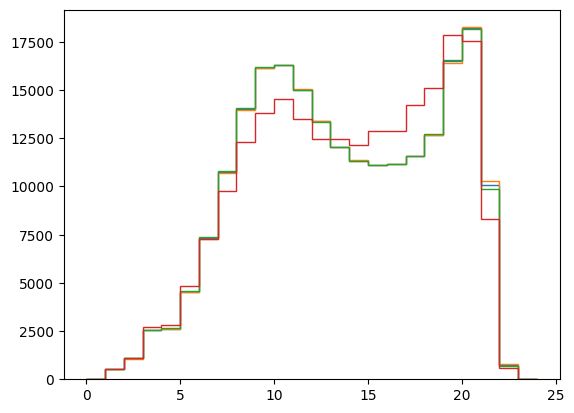

In [ ]:
plt.stairs(sys_matrix_dic_up['nominal'].sum(axis = (0,1,2)), label = 'nominal')
plt.stairs(sys_matrix_dic_up['JMSUp'].sum(axis = (0,1,2)), label = 'JMRUp')
plt.stairs(sys_matrix_dic_down['JMSDown'].sum(axis = (0,1,2)), label = 'Down')
plt.stairs(541*sys_matrix_dic_down['herwigDown'].sum(axis = (0,1,2)), label = 'Down')

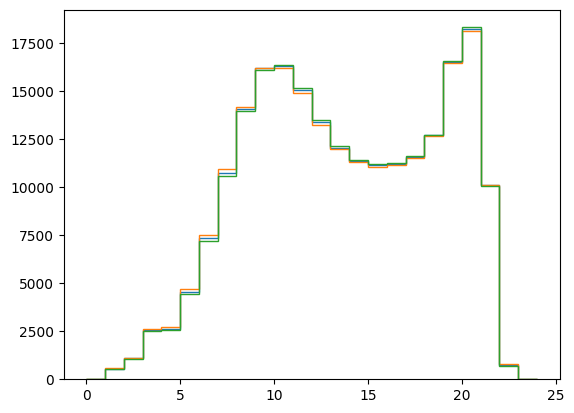

In [ ]:
plt.stairs(sys_matrix_dic_up['nominal'].sum(axis = (0,1,2)), label = 'nominal')
plt.stairs(sys_matrix_dic_up['JMRUp'].sum(axis = (0,1,2)), label = 'JMRUp')
plt.stairs(sys_matrix_dic_down['JMRDown'].sum(axis = (0,1,2)), label = 'Down')


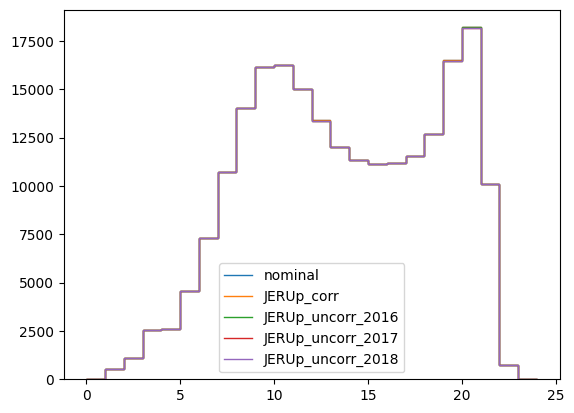

In [ ]:
plt.stairs(sys_matrix_dic_up['nominal'].sum(axis = (0,1,2)))
plt.stairs(sys_matrix_dic_up['JERUp_corr'].sum(axis = (0,1,2)))
plt.stairs(sys_matrix_dic_up['JERUp_uncorr_2016'].sum(axis = (0,1,2)))
plt.stairs(sys_matrix_dic_up['JERUp_uncorr_2017'].sum(axis = (0,1,2)))
plt.stairs(sys_matrix_dic_up['JERUp_uncorr_2018'].sum(axis = (0,1,2)))
plt.legend(['nominal', 'JERUp_corr', 'JERUp_uncorr_2016', 'JERUp_uncorr_2017', 'JERUp_uncorr_2018'])

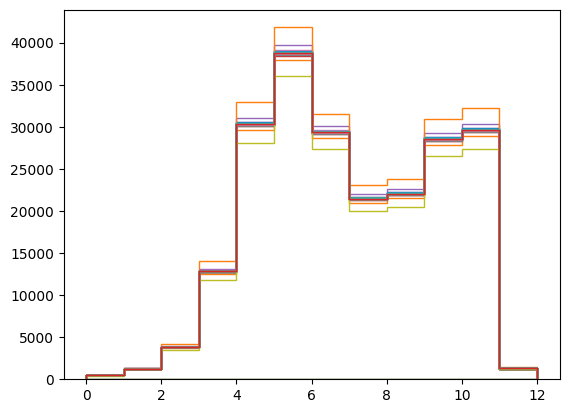

In [ ]:
import matplotlib.pyplot as plt
for key in sys_matrix_dic_up.keys():
    plt.stairs(sys_matrix_dic_up[key].sum(axis = (0,2,3)), label=key)
for key in sys_matrix_dic_down.keys():
    plt.stairs(sys_matrix_dic_down[key].sum(axis = (0,2,3)), label=key)
#plt.yscale('log')

In [8]:
out_dict = {}
for i, file in enumerate(filename_jk_data):
    with open(file, "rb") as f:
        data_jk = pkl.load(f)
        if i ==0:
                out_dict['ptjet_rhojet_g_reco'] = data_jk['ptjet_rhojet_g_reco'].project('jk','ptreco', 'mpt_reco', 'systematic')
                out_dict['ptjet_rhojet_u_reco'] = data_jk['ptjet_rhojet_u_reco'].project('jk','ptreco', 'mpt_reco', 'systematic')
        else:
            out_dict['ptjet_rhojet_g_reco'] += data_jk['ptjet_rhojet_g_reco'].project('jk','ptreco', 'mpt_reco', 'systematic')

            out_dict['ptjet_rhojet_u_reco'] += data_jk['ptjet_rhojet_u_reco'].project('jk','ptreco', 'mpt_reco', 'systematic')

# dump
with open(prepend + 'jk_data.pkl', 'wb') as f:
    pkl.dump(out_dict, f)

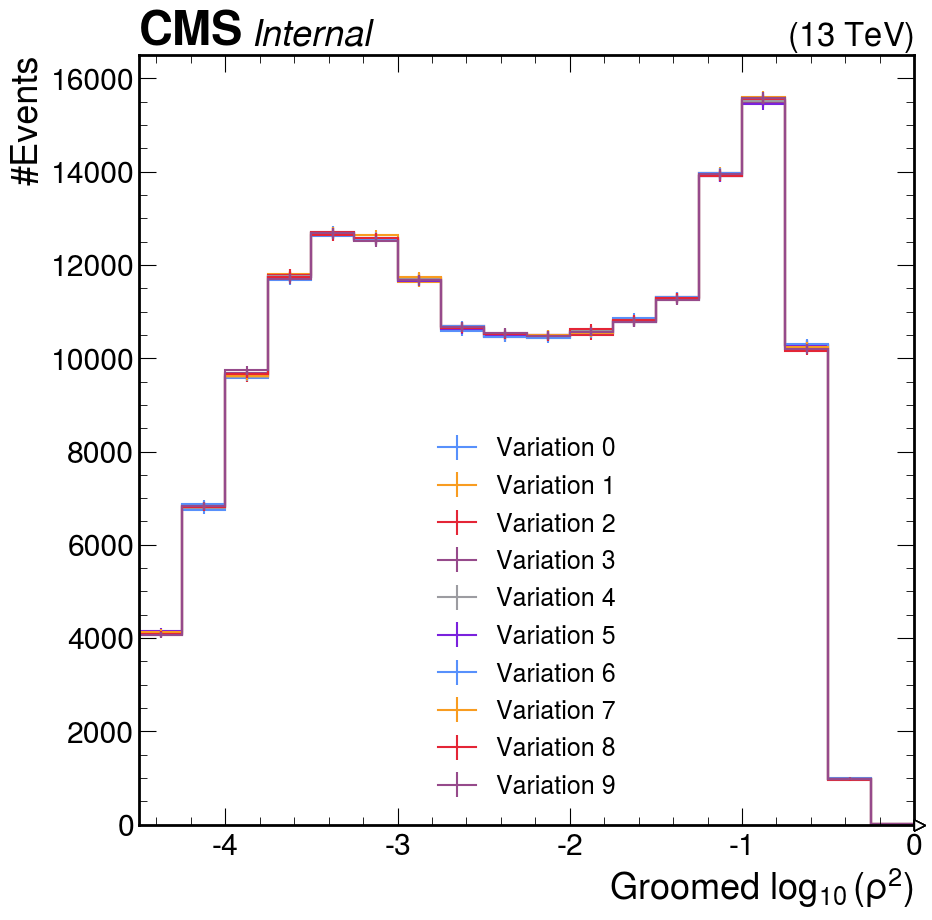

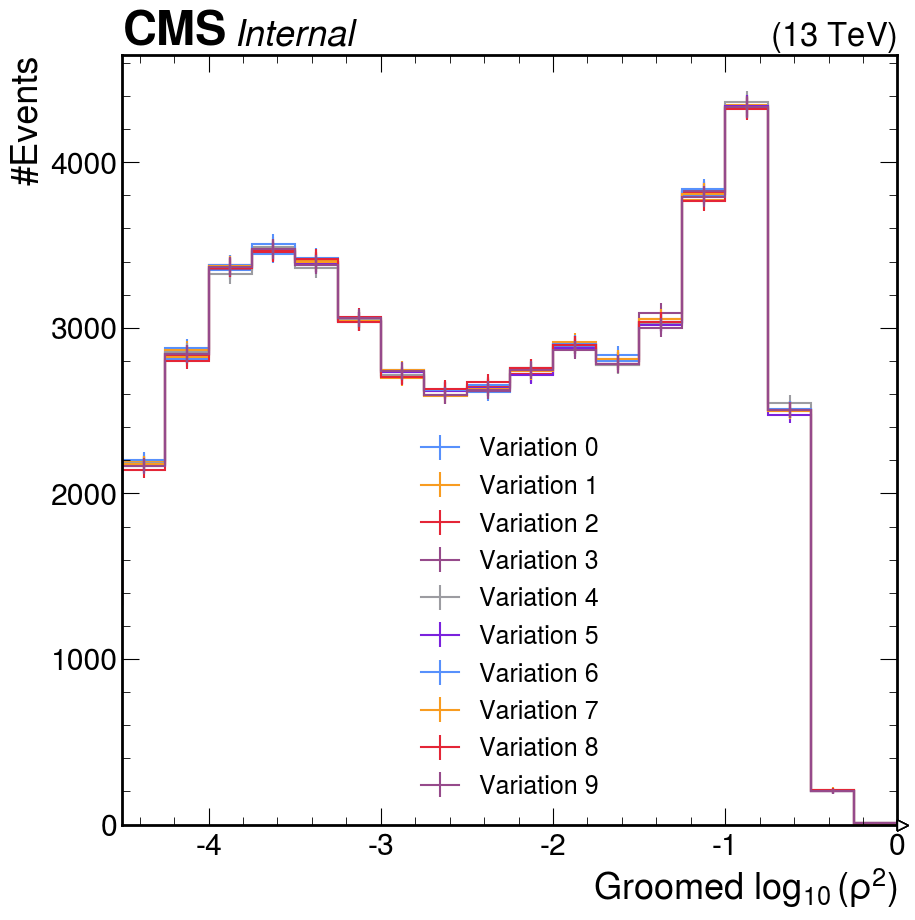

In [17]:
import mplhep as hep
import matplotlib.pyplot as plt
hep.style.use("CMS")  # Use the CMS style for plots

for i in range(1, 3):
    for jk in range(10):
        out_dict['ptjet_rhojet_g_reco'].project('jk', 'ptreco', 'mpt_reco')[jk, i, :].plot(label = f"Variation {jk}")
    plt.xlim(-4.5, 0)
    plt.xlabel(r"Groomed $\log_{10}(\rho^2)$")
    plt.ylabel("#Events")
    plt.legend(fontsize = 18)
    hep.cms.label("Internal", data = True)
    plt.show()

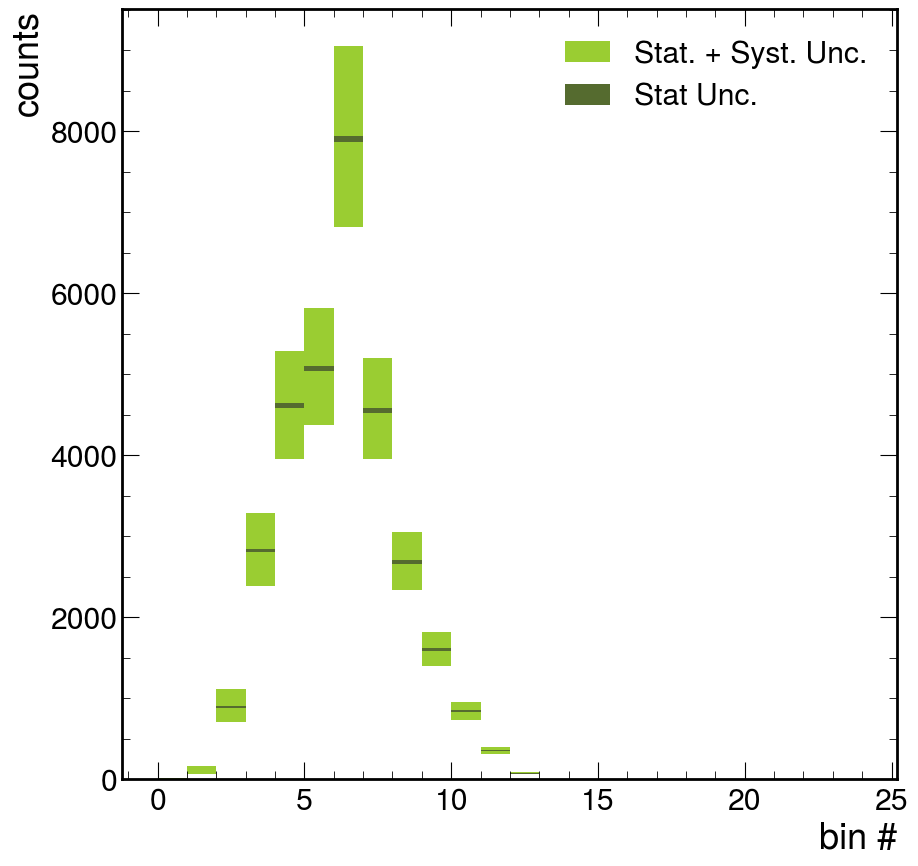

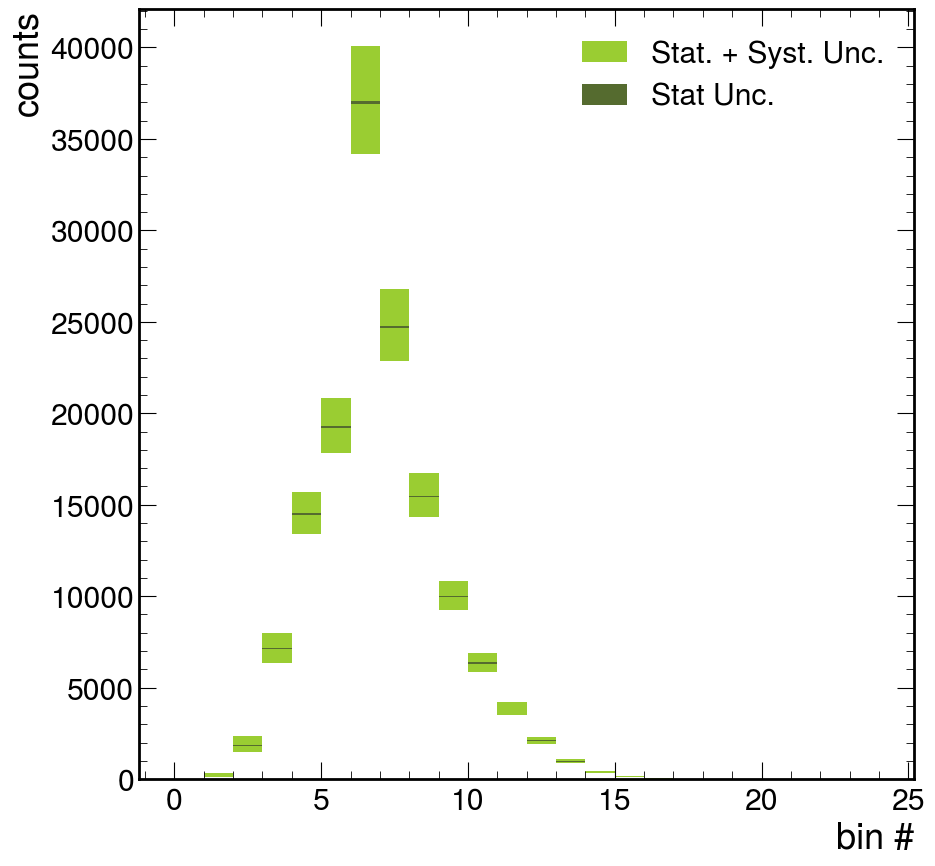

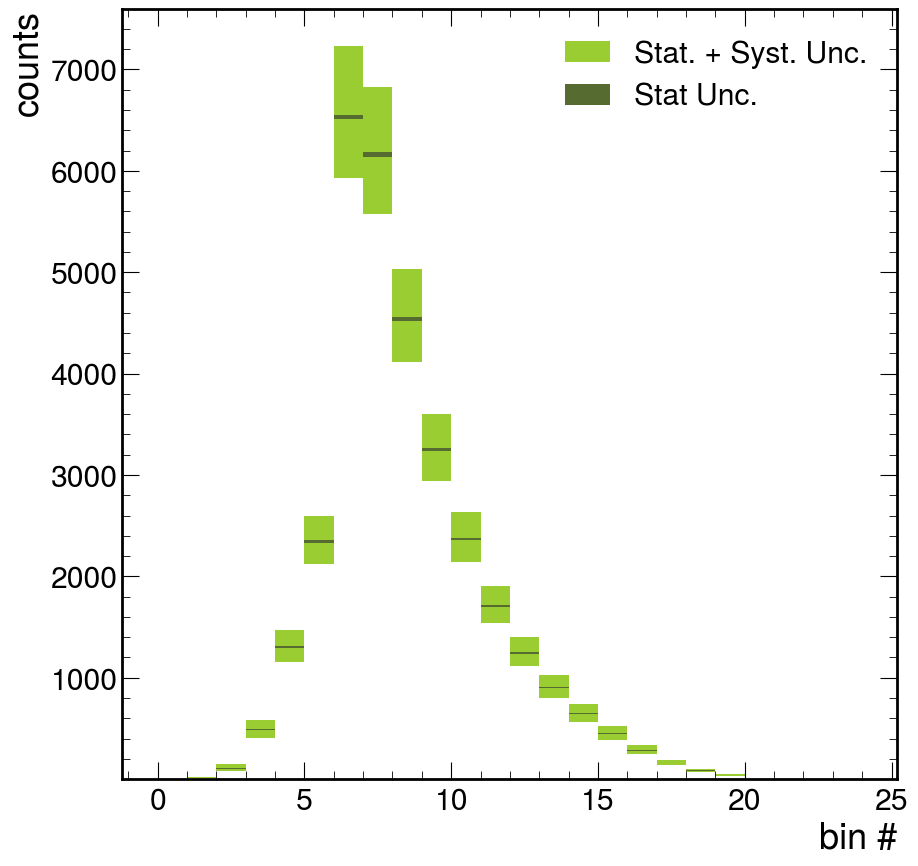

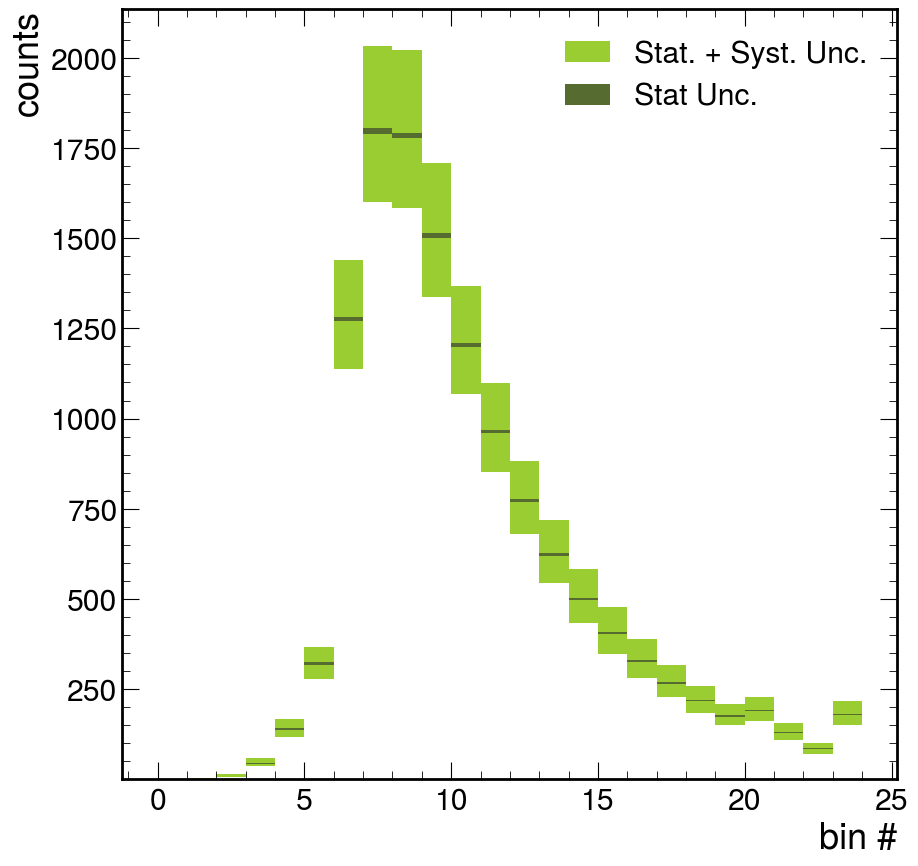

In [ ]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mreco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mreco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        mreco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mreco_nom)
    for key in sys_matrix_dic_down.keys():
        mreco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mreco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mreco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()

In [ ]:
response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco')

Hist(
  Variable([0, 200, 290, 400, 13000], name='ptgen', label='$p_{T,GEN}$ (GeV)'),
  Variable([-10, -6, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0], name='mpt_gen', label='$-\\rho$'),
  Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
  Variable(array([-10.  ,  -8.  ,  -6.  ,  -5.5 ,  -5.  ,  -4.75,  -4.5 ,  -4.25,
        -4.  ,  -3.75,  -3.5 ,  -3.25,  -3.  ,  -2.75,  -2.5 ,  -2.25,
        -2.  ,  -1.75,  -1.5 ,  -1.25,  -1.  ,  -0.75,  -0.5 ,  -0.25,
         0.  ]), name='mpt_reco', label='$-\\rho$ (Detector)'),
  storage=Weight()) # Sum: WeightedSum(value=98205.8, variance=12702.9)

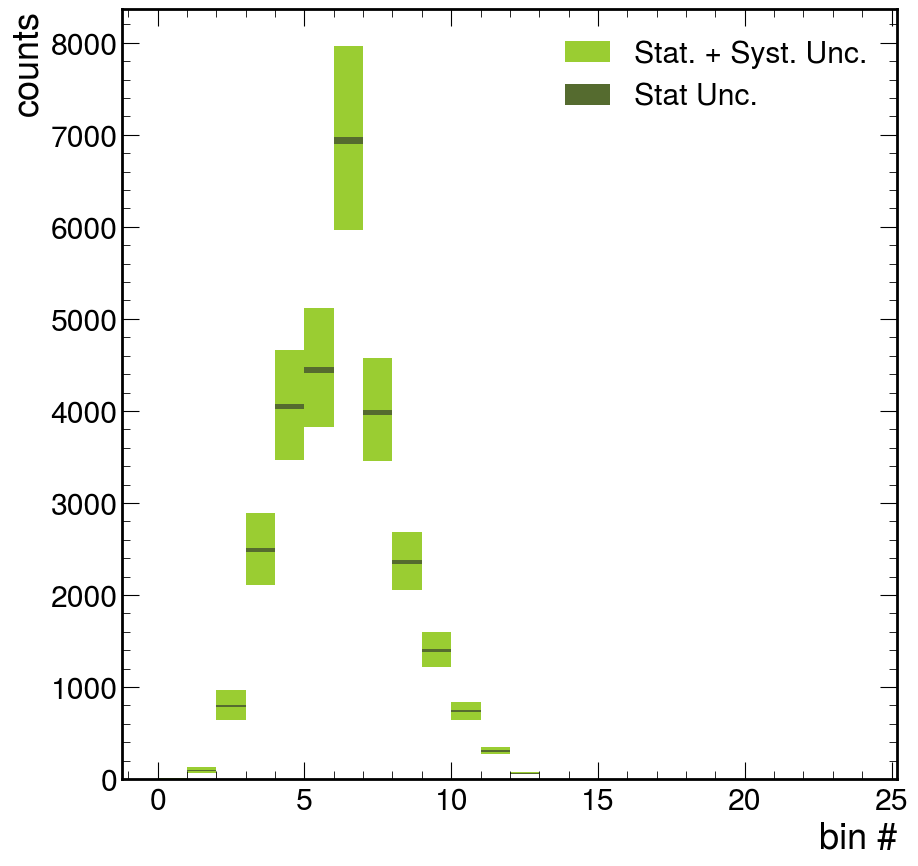

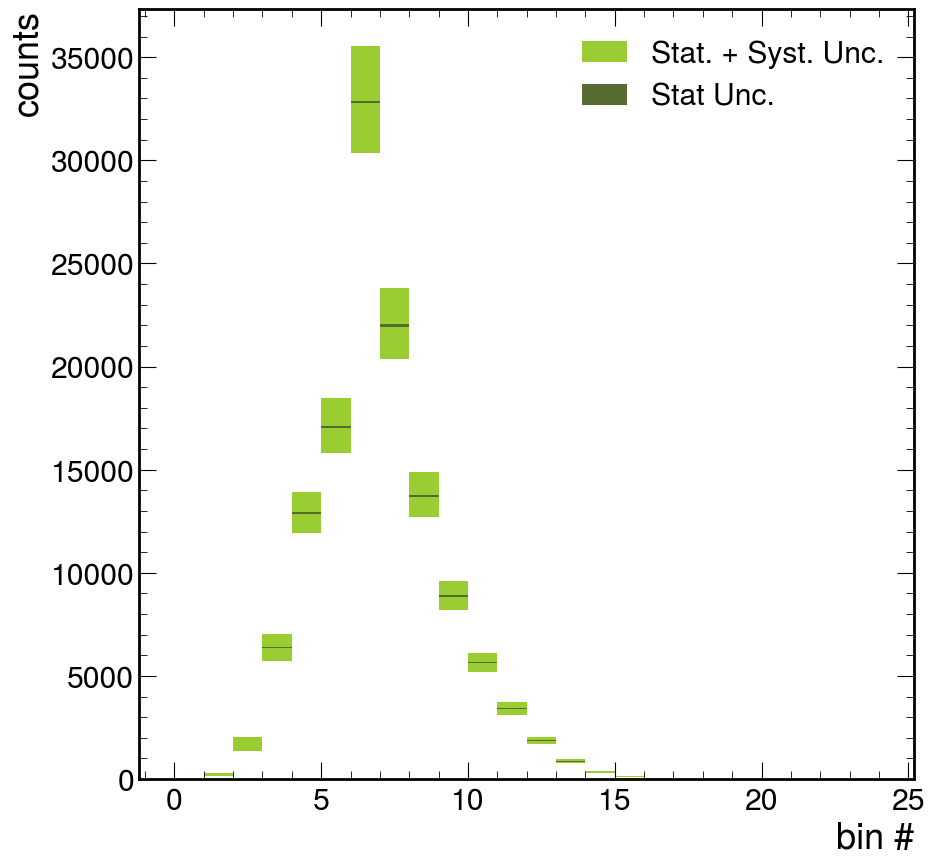

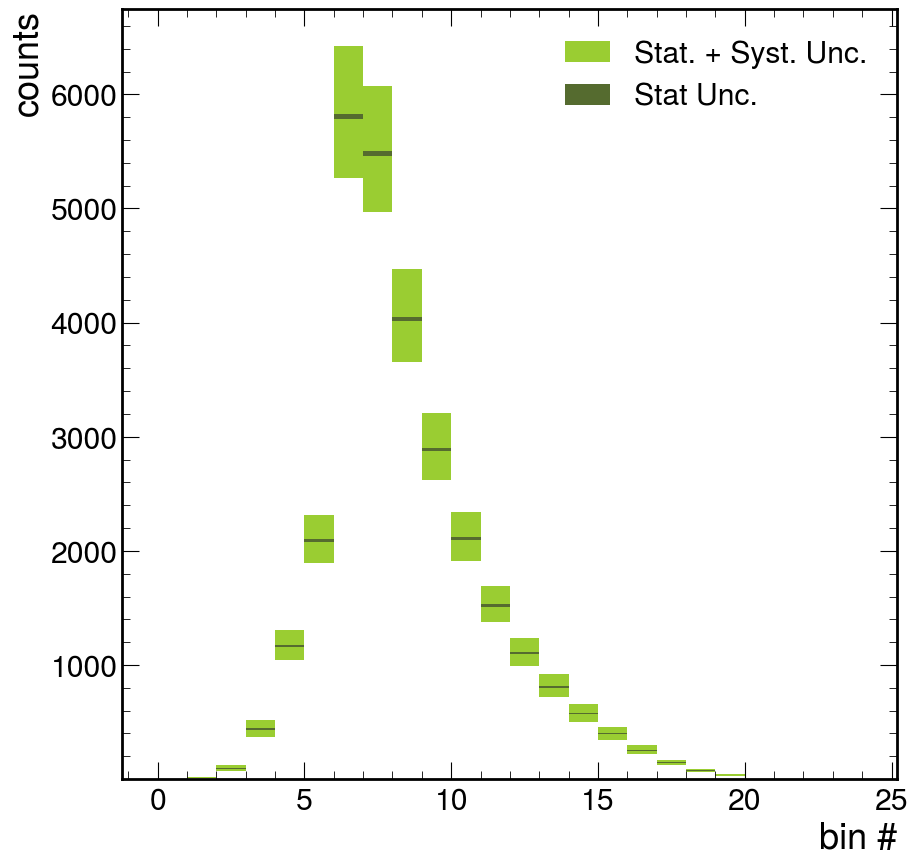

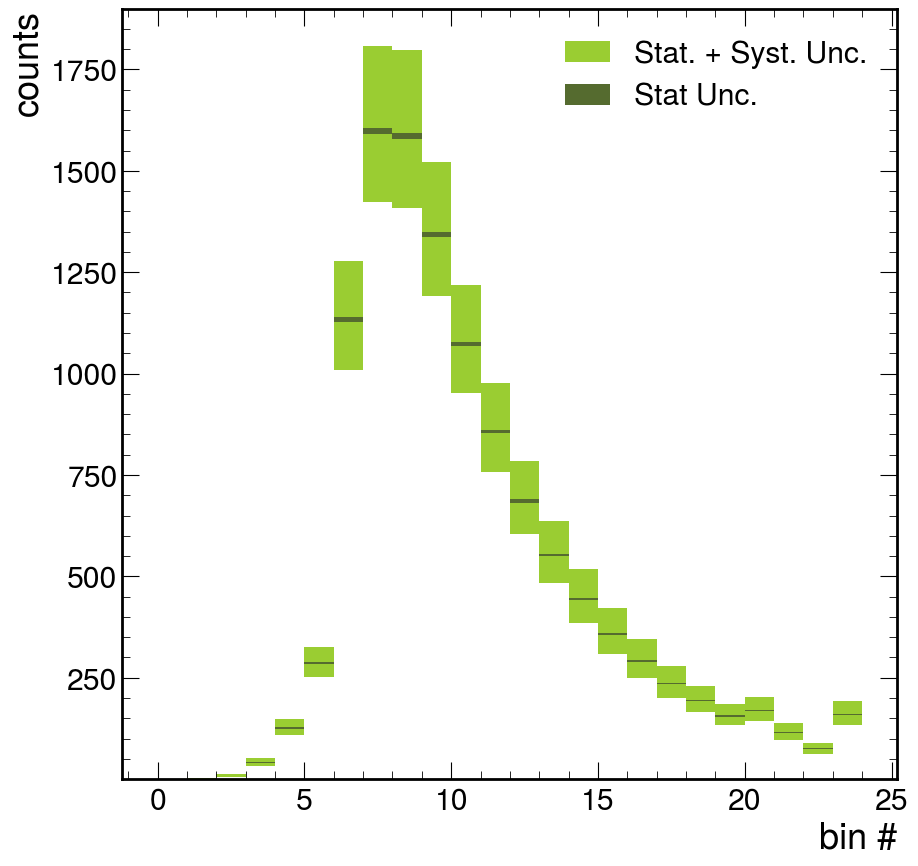

In [ ]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mreco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mreco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        mreco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mreco_nom)
    for key in sys_matrix_dic_down.keys():
        mreco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mreco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mreco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()